# Imports and data loading
The necessary libraries are imported below.

In [139]:
import multiprocessing
multiprocessing.set_start_method('spawn', force=True)

In [140]:
import json
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import perf_counter
from scipy import stats
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix

# Keras with PyTorch backend
import os
os.environ["KERAS_BACKEND"] = "torch"
import torch
import keras
import keras_tuner
from keras import Sequential
from keras.metrics import F1Score
from keras.optimizers import Adam
from keras.layers import Conv1D, Dropout, LSTM, Dense
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [141]:
print(f"PyTorch sees CUDA: {torch.cuda.is_available()}")
print(f"Keras Backend: {keras.config.backend()}")

PyTorch sees CUDA: True
Keras Backend: torch


First, raw data from a subject's experiment is loaded from the JSON file obtained from the Sensor Logger app. This is converted to a Pandas DataFrame using the following function.

In [142]:
def load_subject(filepath: str, subject_id: int) -> dict[str, pd.DataFrame]:
    """
    Load the raw data for a subject's experiment and return
    a dictionary with Pandas DataFrames.
    """
    with open(f"data/{filepath}", 'r') as f:
        records = json.load(f)

    column_names = set(key for r in records for key in r.keys())
    example_values = [example_value for example_value in records[0].values()]
    sensor_data = [r for r in records if r['sensor'] not in ('Metadata', 'Tags')]
    sensor_names = set(r['sensor'] for r in sensor_data)
    dfs: dict[str, pd.DataFrame] = {}

    print(f"Loaded experiment data from: {filepath}")
    print(f"Subject ID: {subject_id}")
    print(f"Column names: {column_names}")
    print(f"Example values: {example_values}\n")
    print(f"--- Sensors ---")
    
    for name in sensor_names:
        print(f"{name}:")

        # Create a DataFrame for this sensor
        rows = [r for r in sensor_data if r['sensor'] == name]
        df = pd.DataFrame(rows)

        # Set the DataFrame's index to the datetime
        df['time'] = pd.to_numeric(df['time'])
        df['time'] = pd.to_datetime(df['time'], unit='ns')
        df = df.sort_values('time').reset_index(drop=True)  # discard old index

        # The time column is used, so discard second_elapsed.
        # We create a DataFrame for each sensor and store the sensor name
        # in the dictionary key, so drop the sensor column.
        df = df.drop(columns=['sensor', 'seconds_elapsed'], errors='ignore')

        # Convert the values to numeric values, where
        # conversion failures yield NaN values.
        for col in df.columns:
            print(f"- {col}")
            if col != 'time':
                df[col] = pd.to_numeric(df[col], errors='coerce')  # error -> NaN
        print()

        # Add the subject ID as a column and store the DataFrame in the dictionary
        df['subject'] = subject_id
        dfs[name] = df

    print("DataFrame created successfully.")
    print("-" * 50)
    
    return dfs

subject1_dfs = load_subject(
    'subject_1_minutes_25_typing_writing_drawing-2026-06-06_18-30-20.json',
    subject_id=1
)

Loaded experiment data from: subject_1_minutes_25_typing_writing_drawing-2026-06-06_18-30-20.json
Subject ID: 1
Column names: {'recording epoch time', 'z', 'version', 'platform', 'altitude', 'bearing', 'qx', 'latitude', 'bpm', 'qw', 'qz', 'longitude', 'recording time', 'appVersion', 'relativeAltitude', 'device id', 'roll', 'yaw', 'speedAccuracy', 'device name', 'qy', 'standardisation', 'tag', 'pressure', 'y', 'sampleRateMs', 'sensor', 'sensors', 'horizontalAccuracy', 'x', 'pitch', 'time', 'recording timezone', 'seconds_elapsed', 'speed', 'bearingAccuracy', 'verticalAccuracy'}
Example values: ['HeartRate', '1780770621882000000', '1.208999755859375', '0']

--- Sensors ---
WatchGyroscope:
- time
- y
- z
- x

WatchAccelerometer:
- time
- y
- z
- x

HeartRate:
- time
- bpm

WatchGravity:
- time
- y
- z
- x

WatchBarometer:
- time
- relativeAltitude
- pressure

WatchOrientation:
- time
- qy
- qx
- yaw
- qw
- qz
- roll
- pitch

WatchLocation:
- time
- bearingAccuracy
- verticalAccuracy
- hori

The DataFrame for subject 1 (train) has been created. In the following cell, the loading function is used to create the DataFrame for subject 2 (test).

In [143]:
subject2_dfs = load_subject(
    'subject_2_minutes_25_typing_writing_drawing-2026-06-06_19-07-40.json',
    subject_id=2
)

Loaded experiment data from: subject_2_minutes_25_typing_writing_drawing-2026-06-06_19-07-40.json
Subject ID: 2
Column names: {'recording epoch time', 'z', 'version', 'platform', 'altitude', 'bearing', 'qx', 'latitude', 'bpm', 'qw', 'qz', 'longitude', 'recording time', 'appVersion', 'relativeAltitude', 'device id', 'roll', 'yaw', 'speedAccuracy', 'device name', 'qy', 'standardisation', 'tag', 'pressure', 'y', 'sampleRateMs', 'sensor', 'sensors', 'horizontalAccuracy', 'x', 'pitch', 'time', 'recording timezone', 'seconds_elapsed', 'speed', 'bearingAccuracy', 'verticalAccuracy'}
Example values: ['Metadata', '3', 'SM-L330', '1780772860505', '2026-06-06_19-07-40', 'Europe/Amsterdam', 'android', '1.58.1', 'SM-L330', 'heartrate|orientation|accelerometer|gravity|gyroscope|totalacceleration|location|barometer|magnetometer', '10|10|10|10|10|10|10|10|10', 'null']

--- Sensors ---
WatchGyroscope:
- time
- y
- z
- x

WatchAccelerometer:
- time
- y
- z
- x

HeartRate:
- time
- bpm

WatchGravity:
- t

For the validation set, subject 1 recorded themselves performing the writing, drawing, and typing activities for a total of ca. 7 minutes. This dataset is given Subject ID 3.

In [144]:
subject3_dfs = load_subject(
    'subject_1b_minutes_7_typing_writing_drawing-2026-06-18_06-30-22.json',
    subject_id=3
)

Loaded experiment data from: subject_1b_minutes_7_typing_writing_drawing-2026-06-18_06-30-22.json
Subject ID: 3
Column names: {'recording epoch time', 'z', 'version', 'platform', 'altitude', 'bearing', 'qx', 'latitude', 'bpm', 'qw', 'qz', 'longitude', 'recording time', 'appVersion', 'relativeAltitude', 'device id', 'roll', 'yaw', 'speedAccuracy', 'device name', 'qy', 'standardisation', 'pressure', 'tag', 'y', 'sampleRateMs', 'sensor', 'sensors', 'horizontalAccuracy', 'x', 'pitch', 'time', 'recording timezone', 'seconds_elapsed', 'speed', 'bearingAccuracy', 'verticalAccuracy'}
Example values: ['HeartRate', '1781764223563000000', '1.195', '57']

--- Sensors ---
WatchGyroscope:
- time
- y
- z
- x

WatchAccelerometer:
- time
- y
- z
- x

HeartRate:
- time
- bpm

WatchGravity:
- time
- y
- z
- x

WatchBarometer:
- time
- relativeAltitude
- pressure

WatchOrientation:
- time
- qy
- qx
- yaw
- qw
- qz
- roll
- pitch

WatchLocation:
- time
- bearingAccuracy
- verticalAccuracy
- horizontalAccur

Next, the data of each individual experiment is merged into a single DataFrame sensor-by-sensor.

In [145]:
# Take the union of the sensor names from both experiments
all_sensors = set(subject1_dfs.keys()) | set(subject2_dfs.keys() | set(subject3_dfs.keys()))

# Concatenate ('group-by-sensor'), stitching the data from subject 2 to the 
# back of the data from subject 1, and subject 3 (=1b) to the back of subject 2, 
# then sort by time (first recorded first)
sensor_dfs = {}
print(f"Sensor names:")
for sensor in all_sensors:
    print(f"- {sensor}")
    parts = []
    if sensor in subject1_dfs:
        parts.append(subject1_dfs[sensor])
    if sensor in subject2_dfs:
        parts.append(subject2_dfs[sensor])
    if sensor in subject3_dfs:
        parts.append(subject3_dfs[sensor])
    sensor_dfs[sensor] = pd.concat(parts, ignore_index=True).sort_values('time').reset_index(drop=True)

Sensor names:
- WatchGyroscope
- WatchAccelerometer
- HeartRate
- WatchGravity
- WatchBarometer
- WatchOrientation
- WatchLocation
- WatchTotalAcceleration
- WatchMagnetometer


The raw sensor data is recorded at 100 Hz (i.e., $\Delta t = 0.01 s$), but there could be jitter. The following cell gives the frequency distribution of sampling intervals for the accelerometer data.

In [146]:
acc_df = sensor_dfs['WatchAccelerometer']
intervals = acc_df['time'].diff().value_counts()
print(intervals)

time
0 days 00:00:00.010059       1026
0 days 00:00:00.010048        974
0 days 00:00:00.010058        913
0 days 00:00:00.010069        832
0 days 00:00:00.010070        807
                             ... 
0 days 00:00:00.010282400       1
0 days 00:00:00.009945500       1
0 days 00:00:00.010299700       1
0 days 00:00:00.009757700       1
0 days 00:00:00.009935300       1
Name: count, Length: 13172, dtype: int64


The sampling interval is not exactly 0.01 second (i.e., 00\:00\:00.01) between each observation. Next, the data is resampled to ensure alignment.

In [147]:
def resample_sensor(df: pd.DataFrame, sensor_name: str) -> pd.DataFrame:
    """
    Resample the data for a specific sensor 
    to ensure sample interval alignment.
    """
    results = []
    for subject_id, group in df.groupby('subject'):
        group = group.set_index('time').drop(columns='subject')
        group = group.resample('10ms').mean()  # ensure interval alignment
        group = group.ffill()  # forward fill NaN values
        
        # Rename the columns, e.g., WatchAccelerometer_x
        group.columns = [f'{sensor_name}_{col}' for col in group.columns]
        
        group['subject'] = subject_id
        results.append(group)
        
    return pd.concat(results)

resampled: dict[str, pd.DataFrame] = {sensor: resample_sensor(df, sensor) for sensor, df in sensor_dfs.items()}

The resampled data for each subject is merged into a single DataFrame separately. Then, the subject DataFrames are concatenated.

In [148]:
def merge_resampled(
    subject_ids: list[int], 
    df_dict: dict[str, pd.DataFrame]
) -> pd.DataFrame:
    """
    Merge the resampled df_dict into a single
    Pandas DataFrame for the specified subject_ids.
    """
    merged_subjects = []
    for subj_id in subject_ids:
        parts = []

        # Get the DataFrame (i.e., part) for this subject-sensor combination
        for sensor, df in df_dict.items():
            subj_df = df[df['subject'] == subj_id].drop(columns='subject')
            parts.append(subj_df)

        # Merge the parts into a single DataFrame for this subject,
        # using the time as index and sorting it lexicographically (outer)
        subj_merged = parts[0].join(parts[1:], how='outer')
        subj_merged['subject'] = subj_id  # reintroduce Subject ID
        merged_subjects.append(subj_merged)

    # Merge the subject DataFrames into a single DataFrame, adding the 
    # old 'time' index as a column, resetting the index to 0, 1, 2, etc. 
    merged_df = pd.concat(merged_subjects).reset_index()

    # Print dataset statistics
    print("--- Number of instances per subject ---")
    print(merged_df['subject'].value_counts())
    print(f"Shape: {merged_df.shape}\n")
    
    print("--- Frequency distribution of sampling rate ---")
    time_diffs = merged_df['time'].diff()
    print(time_diffs.value_counts())
    weird_delta = time_diffs[time_diffs != '0 days 00:00:00.010000']
    
    print("\n--- Weird time delta ---")
    print(weird_delta)

    print("\n--- NaN value counts ---")
    print(merged_df.isnull().sum())

    return merged_df

merged = merge_resampled([1, 2, 3], resampled)

--- Number of instances per subject ---
subject
2    151726
1    151027
3     42339
Name: count, dtype: int64
Shape: (345092, 36)

--- Frequency distribution of sampling rate ---
time
0 days 00:00:00.010000     345089
0 days 00:12:09.470000          1
11 days 10:57:24.700000         1
Name: count, dtype: int64

--- Weird time delta ---
0                            NaT
151027    0 days 00:12:09.470000
302753   11 days 10:57:24.700000
Name: time, dtype: timedelta64[ns]

--- NaN value counts ---
time                                  0
WatchGyroscope_y                      6
WatchGyroscope_z                      6
WatchGyroscope_x                      6
WatchAccelerometer_y                  0
WatchAccelerometer_z                  0
WatchAccelerometer_x                  0
HeartRate_bpm                       567
WatchGravity_y                        9
WatchGravity_z                        9
WatchGravity_x                        9
WatchBarometer_relativeAltitude      43
WatchBarometer_pressur

Now, the $\Delta t$ is consistent. The only 'weird' time delta is found at the start time point of the dataset for both the second and third experiments. Indeed, the second subject did not start recording data immediately after the first subject had finished their experiment. Thus, the different time delta is not an error, but expected.

# Data Exploration

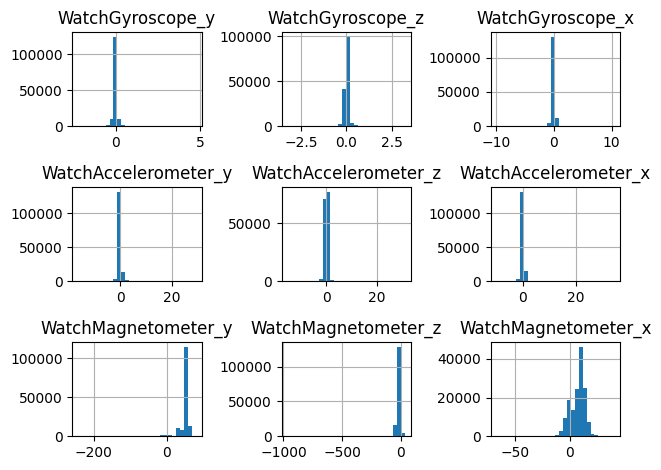

In [149]:
motion_cols = [col for col in merged.columns if any(
    s in col for s in ['WatchAccelerometer', 'WatchGyroscope', 'WatchMagnetometer']
)]

subj1_pre_clean_df = merged[merged['subject'] == 1]
subj1_pre_clean_df[motion_cols].hist(bins=30)
plt.tight_layout()
plt.show()

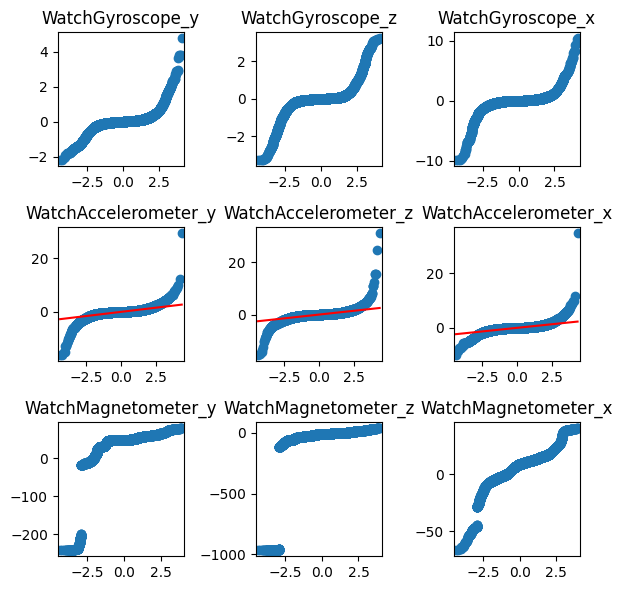

In [150]:
from statsmodels.graphics.gofplots import qqplot
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(6,6))
ax = ax.flatten()
for i, col in enumerate(motion_cols):
    s = subj1_pre_clean_df[col]
    qqplot(s, line='s', ax=ax[i])
    ax[i].set_title(col)
    ax[i].set_xlabel("")
    ax[i].set_ylabel("")
plt.tight_layout()
plt.show()

In [151]:
for col in motion_cols:
    s = subj1_pre_clean_df[col]
    stat, p = stats.normaltest(s, nan_policy='omit')
    print(f'Statistic={stat:.3f}, p={p:e}')

Statistic=63506.186, p=0.000000e+00
Statistic=61919.899, p=0.000000e+00
Statistic=92995.623, p=0.000000e+00
Statistic=56539.279, p=0.000000e+00
Statistic=84901.885, p=0.000000e+00
Statistic=113084.762, p=0.000000e+00
Statistic=235714.712, p=0.000000e+00
Statistic=326541.253, p=0.000000e+00
Statistic=47574.532, p=0.000000e+00


Each D'Agostino's $K^2$ test result gives an extremely small p-value of approximately zero, much smaller than the significance level $\alpha=0.05$. Therefore, for each data series, the null hypothesis $H_0$ that the sample is Gaussian, is rejected. Thus, it is unlikely that the data of any of the motion columns are Gaussian.

# Data Cleaning
In this section, noise is removed from the data and missing values are handled.

In [152]:
def chauvenet_count(series: pd.Series, c=2, visualize=False):
    """
    Chauvenet's criterion: Reject a measurement when the
    probability of observing it is less than 1 / (c*N).

    The data is assumed to follow the standard normal
    distribution.
    
    Given a Pandas Series and the parameter c, a positive 
    constant between 1-10 (default 2) specifying the degree 
    of certainty for outlier identification, return the 
    number of outliers detected.
    """
    # Determine the length of the series N, discarding 
    # NaN values, and set the Chauvenet's criterion
    series = series.copy()
    mask = series.notna()
    vals = series[mask]
    N = len(vals)
    if N == 0:
        return series
    criterion = 1.0 / (c * N)

    # Get the original mean and standard deviation
    mu, sigma = vals.mean(), vals.std()
    
    # Get the probability for each data point using the
    # Normal Cumulative Distribution Function.
    prob = stats.norm.cdf(vals, loc=mu, scale=sigma)

    # An outlier is a point where the following holds:
    # 1-P < 1/cN   OR
    # P < 1/cN
    outlier_mask = (1.0 - prob < criterion) | (prob < criterion)
    outlier_series = vals[outlier_mask]
    result = len(outlier_series)

    if visualize and result > 0:
        signed_z_scores = (vals - mu) / sigma
        print(f"The {series.name} column has {result} outliers after dropping NaN values.")
        print(f"Chauvenet's criterion: 1 / ({c} * {N}) = {criterion:.2e}")
        print(f"Outliers are those data points where (1-P) < {criterion:.2e} or P < {criterion:.2e}\n")
        
        print("Data points on the Standard Normal Distribution:\n")
        z_critical = stats.norm.ppf(1 - criterion)
        draw_min = min(signed_z_scores.min(), -z_critical) - 1
        draw_max = max(signed_z_scores.max(), z_critical) + 1
        x_axis = np.linspace(draw_min, draw_max, 1000)
        y_pdf = stats.norm.pdf(x_axis, loc=0, scale=1)
        data_pdf = stats.norm.pdf(signed_z_scores, loc=0, scale=1)
        xlabel, ylabel = 'z', 'Probability Density'
        bound_label = f"Rejection Boundary (Z = ±{z_critical:.2f})"
        obj = {xlabel: x_axis, ylabel: y_pdf}
        plt.figure()
        plt.plot(xlabel, ylabel, data=obj)
        plt.scatter(signed_z_scores, data_pdf, s=4)
        plt.axvline(z_critical, color='red', label=bound_label, linestyle=':', linewidth=1)
        plt.axvline(-z_critical, color='red', linestyle=':', linewidth=1)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.legend(loc="upper right")
        plt.show()
        
    return result

The above function can be used to count the number of outliers using Chauvenet's criterion. Below, this outlier detection technique is visualized for an example series.

The WatchGyroscope_y column has 3723 outliers after dropping NaN values.
Chauvenet's criterion: 1 / (2 * 345086) = 1.45e-06
Outliers are those data points where (1-P) < 1.45e-06 or P < 1.45e-06

Data points on the Standard Normal Distribution:



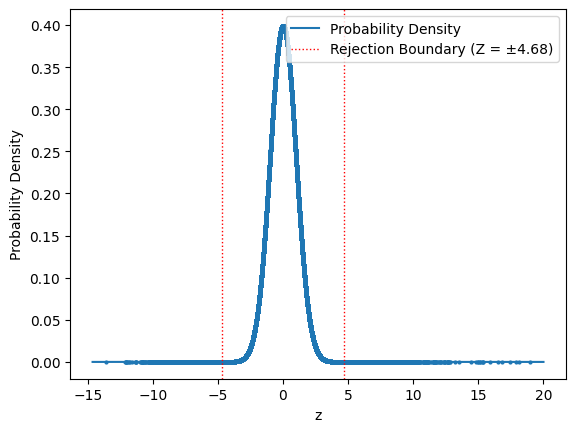

In [153]:
sensor_cols = [col for col in merged.columns if col not in ('time', 'subject')]

# Compute the number of outliers and visualize an example
for col in sensor_cols:
    s = merged[col]
    
    n_chauvenet = chauvenet_count(s, visualize=True)
    
    if n_chauvenet > 0:
        break

In [154]:
merged['HeartRate_bpm'] = merged['HeartRate_bpm'].replace(0, np.nan)
merged_before = merged.copy()

In [155]:
from sklearn.neighbors import LocalOutlierFactor

def lof_flag(df_cols, n_neighbors=20, contamination=0.01):
    mask_valid = df_cols.notna().all(axis=1)
    result = pd.Series(False, index=df_cols.index)
    if mask_valid.sum() < n_neighbors + 1:
        return result
    lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination='auto')

    pred = lof.fit_predict(df_cols[mask_valid])
    result.loc[mask_valid] = (pred == -1)
    return result

lof_groups = {
    'WatchMagnetometer': ['WatchMagnetometer_x', 'WatchMagnetometer_y', 'WatchMagnetometer_z'],
    'WatchGravity': ['WatchGravity_x', 'WatchGravity_y', 'WatchGravity_z'],
}

for group_name, cols in lof_groups.items():
    for subj in [1, 2, 3]:
        mask = merged['subject'] == subj
        outlier_mask = lof_flag(merged.loc[mask, cols])
        merged.loc[mask & outlier_mask.reindex(merged.index, fill_value=False), cols] = np.nan


In [156]:
def chauvenet(series: pd.Series, c=2):
    """
    Chauvenet's criterion: Reject a measurement when the
    probability of observing it is less than 1 / (c*N).

    The data is assumed to follow the standard normal
    distribution.
    
    Given a Pandas Series and the parameter c, a positive 
    constant between 1-10 (default 2) specifying the degree 
    of certainty for outlier identification, replace the 
    values of the outliers by NaN values in the Series.
    """
    # Determine the length of the series N, discarding 
    # NaN values, and set the Chauvenet's criterion
    series = series.copy()
    mask = series.notna()
    vals = series[mask]
    N = len(vals)
    if N == 0:
        return series
    criterion = 1.0 / (c * N)

    # Get the original mean and standard deviation
    mu, sigma = vals.mean(), vals.std()
    
    # Get the probability for each data point using the
    # Normal Cumulative Distribution Function.
    prob = stats.norm.cdf(vals, loc=mu, scale=sigma)

    # An outlier is a point where the following holds:
    # 1-P < 1/cN   OR
    # P < 1/cN
    outlier_mask = (1.0 - prob < criterion) | (prob < criterion)

    # Replace the values of the outliers by NaN values
    series[mask] = series[mask].where(~outlier_mask, np.nan)

    return series

# Select the normally distributed columns from the dataset
chauvenet_cols = [col for col in merged.columns if any(
    s in col for s in ['WatchAccelerometer', 'WatchGyroscope', 'WatchGravity',
                       'WatchTotalAcceleration', 'WatchMagnetometer']
)]

# Replace the values of the outliers by NaN values
for col in chauvenet_cols:
    for subj in [1, 2, 3]:
        mask = merged['subject'] == subj
        merged.loc[mask, col] = chauvenet(merged.loc[mask, col])

In [157]:
merged_after = merged.copy()

## Linear interpolation for all remaining missing values
Interpolation is preferred over mean imputation for temporal data as it respects the trend between surrounding measurements. Applied per subject to avoid interpolating across recording boundaries. The `ffill` and `bfill` methods handle edges where interpolation cannot extrapolate.

In [158]:
# Interpolate per subject for NaN values
for col in [c for c in merged.columns if c not in ('time', 'subject')]:
    for subj in [1, 2, 3]:
        mask = merged['subject'] == subj
        merged.loc[mask, col] = (
            merged.loc[mask, col]
            .interpolate(method='linear')
            .ffill()
            .bfill()
        )

print("Missing values remaining after interpolation:")
missing = merged.isnull().sum()
print(missing[missing > 0] if missing.any() else "None")

Missing values remaining after interpolation:
None


In [159]:
rows = []
for col in chauvenet_cols:
    n = merged_after[col].isna().sum() - merged_before[col].isna().sum()
    rows.append({'column': col, 'method': 'Chauvenet', 'flagged': n, 'flagged_%': round(100*n/len(merged), 3)})

for group_name, cols in lof_groups.items():
    for col in cols:
        n = merged_after[col].isna().sum() - merged_before[col].isna().sum()
        rows.append({'column': col, 'method': 'LOF', 'flagged': n, 'flagged_%': round(100*n/len(merged), 3)})

outlier_report = pd.DataFrame(rows)
print(outlier_report)

                      column     method  flagged  flagged_%
0           WatchGyroscope_y  Chauvenet     3901      1.130
1           WatchGyroscope_z  Chauvenet     3896      1.129
2           WatchGyroscope_x  Chauvenet     3021      0.875
3       WatchAccelerometer_y  Chauvenet     2566      0.744
4       WatchAccelerometer_z  Chauvenet     2514      0.729
5       WatchAccelerometer_x  Chauvenet     2944      0.853
6             WatchGravity_y  Chauvenet     9409      2.727
7             WatchGravity_z  Chauvenet     8851      2.565
8             WatchGravity_x  Chauvenet    10153      2.942
9   WatchTotalAcceleration_y  Chauvenet      616      0.179
10  WatchTotalAcceleration_z  Chauvenet      463      0.134
11  WatchTotalAcceleration_x  Chauvenet     1805      0.523
12       WatchMagnetometer_y  Chauvenet     5729      1.660
13       WatchMagnetometer_z  Chauvenet     5755      1.668
14       WatchMagnetometer_x  Chauvenet     5907      1.712
15       WatchMagnetometer_x        LOF 

## Skew and kurtosis

In [160]:
from scipy.stats import skew, kurtosis

print("missing values per column before cleaning:")
sensor_cols = [col for col in merged_before.columns if col not in ('time', 'subject')]
rows = []
for col in sensor_cols:
    s = merged_before[col]
    rows.append({
        'column': col,
        'missing_%': round(100 * s.isna().sum() / len(s), 2),
        'zero_%': round(100 * (s == 0).sum() / len(s), 2),
    })
print(pd.DataFrame(rows).set_index('column'))

missing values per column before cleaning:
                                  missing_%  zero_%
column                                             
WatchGyroscope_y                       0.00    0.82
WatchGyroscope_z                       0.00    1.13
WatchGyroscope_x                       0.00    0.54
WatchAccelerometer_y                   0.00    0.56
WatchAccelerometer_z                   0.00    0.71
WatchAccelerometer_x                   0.00    1.22
HeartRate_bpm                          2.44    0.00
WatchGravity_y                         0.00    0.00
WatchGravity_z                         0.00    0.00
WatchGravity_x                         0.00    0.00
WatchBarometer_relativeAltitude        0.01    0.63
WatchBarometer_pressure                0.01    0.00
WatchOrientation_qy                    0.00    0.00
WatchOrientation_qx                    0.00    0.00
WatchOrientation_yaw                   0.00    0.00
WatchOrientation_qw                    0.00    0.00
WatchOrientation_qz  

In [161]:
print("skew and kurtosis, post-cleaning, columns checked for normality:")
for col in chauvenet_cols:
    s = merged[col].dropna()
    print(f"{col}: skew={skew(s):.2f}, kurtosis={kurtosis(s):.2f}")

skew and kurtosis, post-cleaning, columns checked for normality:
WatchGyroscope_y: skew=0.02, kurtosis=14.51
WatchGyroscope_z: skew=-0.01, kurtosis=21.71
WatchGyroscope_x: skew=-0.15, kurtosis=13.41
WatchAccelerometer_y: skew=-0.04, kurtosis=7.08
WatchAccelerometer_z: skew=-0.51, kurtosis=6.80
WatchAccelerometer_x: skew=-0.25, kurtosis=9.13
WatchGravity_y: skew=1.30, kurtosis=1.17
WatchGravity_z: skew=-0.53, kurtosis=1.01
WatchGravity_x: skew=0.23, kurtosis=3.86
WatchTotalAcceleration_y: skew=1.18, kurtosis=1.12
WatchTotalAcceleration_z: skew=-0.54, kurtosis=1.16
WatchTotalAcceleration_x: skew=0.14, kurtosis=3.76
WatchMagnetometer_y: skew=-1.05, kurtosis=0.98
WatchMagnetometer_z: skew=-1.69, kurtosis=2.33
WatchMagnetometer_x: skew=1.01, kurtosis=1.61


In [162]:
print("skew, columns where LOF was used instead:")
for group_name, cols in lof_groups.items():
    for col in cols:
        s = merged_before[col].dropna()
        print(f"{col}: skew={skew(s):.2f}")

skew, columns where LOF was used instead:
WatchMagnetometer_x: skew=1.08
WatchMagnetometer_y: skew=-2.53
WatchMagnetometer_z: skew=-7.84
WatchGravity_x: skew=0.32
WatchGravity_y: skew=1.33
WatchGravity_z: skew=-0.59


In [163]:
print("outlier removal summary:")
rows = []
for col in chauvenet_cols:
    n = merged_after[col].isna().sum() - merged_before[col].isna().sum()
    rows.append({'column': col, 'method': 'Chauvenet', 'flagged_%': round(100*n/len(merged), 3)})
for group_name, cols in lof_groups.items():
    for col in cols:
        n = merged_after[col].isna().sum() - merged_before[col].isna().sum()
        rows.append({'column': col, 'method': 'LOF', 'flagged_%': round(100*n/len(merged), 3)})
print(pd.DataFrame(rows))

outlier removal summary:
                      column     method  flagged_%
0           WatchGyroscope_y  Chauvenet      1.130
1           WatchGyroscope_z  Chauvenet      1.129
2           WatchGyroscope_x  Chauvenet      0.875
3       WatchAccelerometer_y  Chauvenet      0.744
4       WatchAccelerometer_z  Chauvenet      0.729
5       WatchAccelerometer_x  Chauvenet      0.853
6             WatchGravity_y  Chauvenet      2.727
7             WatchGravity_z  Chauvenet      2.565
8             WatchGravity_x  Chauvenet      2.942
9   WatchTotalAcceleration_y  Chauvenet      0.179
10  WatchTotalAcceleration_z  Chauvenet      0.134
11  WatchTotalAcceleration_x  Chauvenet      0.523
12       WatchMagnetometer_y  Chauvenet      1.660
13       WatchMagnetometer_z  Chauvenet      1.668
14       WatchMagnetometer_x  Chauvenet      1.712
15       WatchMagnetometer_x        LOF      1.712
16       WatchMagnetometer_y        LOF      1.660
17       WatchMagnetometer_z        LOF      1.668
18    

In [164]:
print("missing values remaining after interpolation:")
missing = merged.isnull().sum()
print(missing[missing > 0] if missing.any() else "none")

missing values remaining after interpolation:
none


In [165]:
print("missing values remaining, per subject:")
for subj in [1, 2, 3]:
    missing = merged[merged['subject'] == subj].isnull().sum()
    missing = missing[missing > 0]
    print(f"subject {subj}: {'none' if missing.empty else missing.to_dict()}")

missing values remaining, per subject:
subject 1: none
subject 2: none
subject 3: none


In [166]:
print(merged.columns.tolist())

['time', 'WatchGyroscope_y', 'WatchGyroscope_z', 'WatchGyroscope_x', 'WatchAccelerometer_y', 'WatchAccelerometer_z', 'WatchAccelerometer_x', 'HeartRate_bpm', 'WatchGravity_y', 'WatchGravity_z', 'WatchGravity_x', 'WatchBarometer_relativeAltitude', 'WatchBarometer_pressure', 'WatchOrientation_qy', 'WatchOrientation_qx', 'WatchOrientation_yaw', 'WatchOrientation_qw', 'WatchOrientation_qz', 'WatchOrientation_roll', 'WatchOrientation_pitch', 'WatchLocation_bearingAccuracy', 'WatchLocation_verticalAccuracy', 'WatchLocation_horizontalAccuracy', 'WatchLocation_speedAccuracy', 'WatchLocation_speed', 'WatchLocation_bearing', 'WatchLocation_altitude', 'WatchLocation_longitude', 'WatchLocation_latitude', 'WatchTotalAcceleration_y', 'WatchTotalAcceleration_z', 'WatchTotalAcceleration_x', 'WatchMagnetometer_y', 'WatchMagnetometer_z', 'WatchMagnetometer_x', 'subject']


# Feature Engineering
In this section, features are extracted and the usefulness of those features is analyzed.

## Assign activity labels from recorded timestamps

In [167]:
activity_bounds = {
    1: [
        ('typing',  120, 507),
        ('writing', 533, 1268),
        ('drawing', 1290, 1485),
    ],
    2: [
        ('typing',  21,  464),
        ('writing', 468, 1095),
        ('drawing', 1111, 1309),
    ],
    3: [
        ('typing',  10,  88),
        ('writing', 100, 262),
        ('drawing', 285, 404),
    ],
}

merged['label'] = None

for subj, bounds in activity_bounds.items():
    mask = merged['subject'] == subj
    t0 = merged.loc[mask, 'time'].min()
    elapsed = (merged.loc[mask, 'time'] - t0).dt.total_seconds()
    for activity, t_start, t_end in bounds:
        in_window = mask & (elapsed >= t_start) & (elapsed <= t_end)
        merged.loc[in_window, 'label'] = activity

print(merged['label'].value_counts(dropna=False))

label
writing    152403
typing      90803
drawing     51203
None        50683
Name: count, dtype: int64


## Select accelerometer, gyroscope, and magnetometer columns

In [168]:
df = merged[['time', 'subject', 'label'] + motion_cols].copy()

print(f"Retained {len(motion_cols)} motion sensor columns:")
print(motion_cols)

Retained 9 motion sensor columns:
['WatchGyroscope_y', 'WatchGyroscope_z', 'WatchGyroscope_x', 'WatchAccelerometer_y', 'WatchAccelerometer_z', 'WatchAccelerometer_x', 'WatchMagnetometer_y', 'WatchMagnetometer_z', 'WatchMagnetometer_x']


## Feature extraction over sliding windows

In [169]:
def extract_features(df, motion_cols, window, step, fs=100):
    freqs = np.fft.rfftfreq(window, d=1 / fs)
    freqs_no_dc = freqs[1:]
    rows = []

    for subject in (1, 2):
        subject_df = df[df['subject'] == subject].reset_index(drop=True)
        motion = subject_df[motion_cols].to_numpy()

        for end in range(window - 1, len(subject_df), step):
            label = subject_df.at[end, 'label']

            if pd.isna(label):
                continue

            window_data = motion[end - window + 1:end + 1]

            row = {
                'time': subject_df.at[end, 'time'],
                'subject': subject,
                'label': label
            }

            for i, column in enumerate(motion_cols):
                signal = window_data[:, i]

                spectrum = np.abs(np.fft.rfft(signal))
                spectrum_no_dc = spectrum[1:]
                total_amplitude = spectrum_no_dc.sum()

                power = spectrum ** 2 / window
                total_power = power.sum()

                if total_power > 0:
                    probabilities = power / total_power
                    probabilities = probabilities[probabilities > 0]
                    pse = -np.sum(probabilities * np.log(probabilities))
                else:
                    pse = 0.0

                row.update({
                    f'{column}_mean': signal.mean(),
                    f'{column}_std': signal.std(),
                    f'{column}_min': signal.min(),
                    f'{column}_max': signal.max(),
                    f'{column}_max_freq':
                        freqs_no_dc[np.argmax(spectrum_no_dc)],
                    f'{column}_freq_wavg':
                        np.average(freqs_no_dc, weights=spectrum_no_dc)
                        if total_amplitude > 0 else 0.0,
                    f'{column}_pse': float(pse)
                })

            rows.append(row)

    return pd.DataFrame(rows)


WINDOW = 200
OVERLAP = 0.5
STEP = int(WINDOW * (1 - OVERLAP))

features = extract_features(df, motion_cols, WINDOW, STEP)

print(features['label'].value_counts())
print(features.shape)
features.head()

label
writing    1362
typing      830
drawing     393
Name: count, dtype: int64
(2585, 66)


,time,subject,label,WatchGyroscope_y_mean,WatchGyroscope_y_std,WatchGyroscope_y_min,WatchGyroscope_y_max,WatchGyroscope_y_max_freq,WatchGyroscope_y_freq_wavg,WatchGyroscope_y_pse,...,WatchMagnetometer_z_max_freq,WatchMagnetometer_z_freq_wavg,WatchMagnetometer_z_pse,WatchMagnetometer_x_mean,WatchMagnetometer_x_std,WatchMagnetometer_x_min,WatchMagnetometer_x_max,WatchMagnetometer_x_max_freq,WatchMagnetometer_x_freq_wavg,WatchMagnetometer_x_pse
0,2026-06-06 18:32:21.870,1,typing,0.010232,0.131033,-0.357967,0.324980,1.5,12.705018,3.101142,...,1.0,8.590147,0.054213,-13.085250,13.346185,-24.66,18.059999,0.5,7.514374,1.020042
1,2026-06-06 18:32:22.870,1,typing,0.068625,0.180581,-0.357967,0.488692,0.5,11.485205,2.459825,...,0.5,9.643683,0.295236,-16.282901,5.735032,-24.66,-8.340000,0.5,6.220295,0.254983
2,2026-06-06 18:32:23.870,1,typing,0.070995,0.209961,-0.597426,0.488692,1.5,10.348612,1.995464,...,0.5,10.041086,0.204463,-7.998000,4.953681,-15.78,4.320000,0.5,9.822348,0.675534
3,2026-06-06 18:32:24.870,1,typing,-0.006805,0.185190,-0.597426,0.530231,1.5,10.962401,1.937908,...,0.5,9.163249,0.081403,-2.626500,4.015146,-14.58,4.320000,0.5,11.337145,1.468334
4,2026-06-06 18:32:25.870,1,typing,0.003079,0.163562,-0.260229,0.530231,1.5,11.781478,2.239198,...,1.5,8.443811,0.050621,-0.252600,2.007783,-3.54,4.200000,1.0,9.072096,1.700224


## Compare window sizes

In [170]:
window_sizes = [100, 200, 500]
k = 3

results = []

for window in window_sizes:
    step = int(window * (1 - OVERLAP))
    features = extract_features(df, motion_cols, window, step)

    X = features.drop(columns=['time', 'subject', 'label'])
    y = features['label']

    F = f_classif(X, y)[0]
    N = len(features)
    eta2 = F * (k - 1) / (F * (k - 1) + N - k)

    results.append({
        'window_s': window / 100,
        'instances': window,
        'n_windows': N,
        'mean_eta2': np.nanmean(eta2),
        'mean_F': np.nanmean(F)
    })

window_comparison = pd.DataFrame(results)
print(window_comparison.round(3))

best_index = window_comparison['mean_eta2'].idxmax()
best_row = window_comparison.loc[best_index]

print(
    f"\nMost separable window: {best_row['window_s']:.0f}s "
    f"({best_row['instances']:.0f} instances), "
    f"mean eta2 = {best_row['mean_eta2']:.3f}"
)

   window_s  instances  n_windows  mean_eta2   mean_F
0       1.0        100       5170      0.085  297.463
1       2.0        200       2585      0.096  175.927
2       5.0        500       1033      0.119   96.818

Most separable window: 5s (500 instances), mean eta2 = 0.119


## Analyze feature usefulness

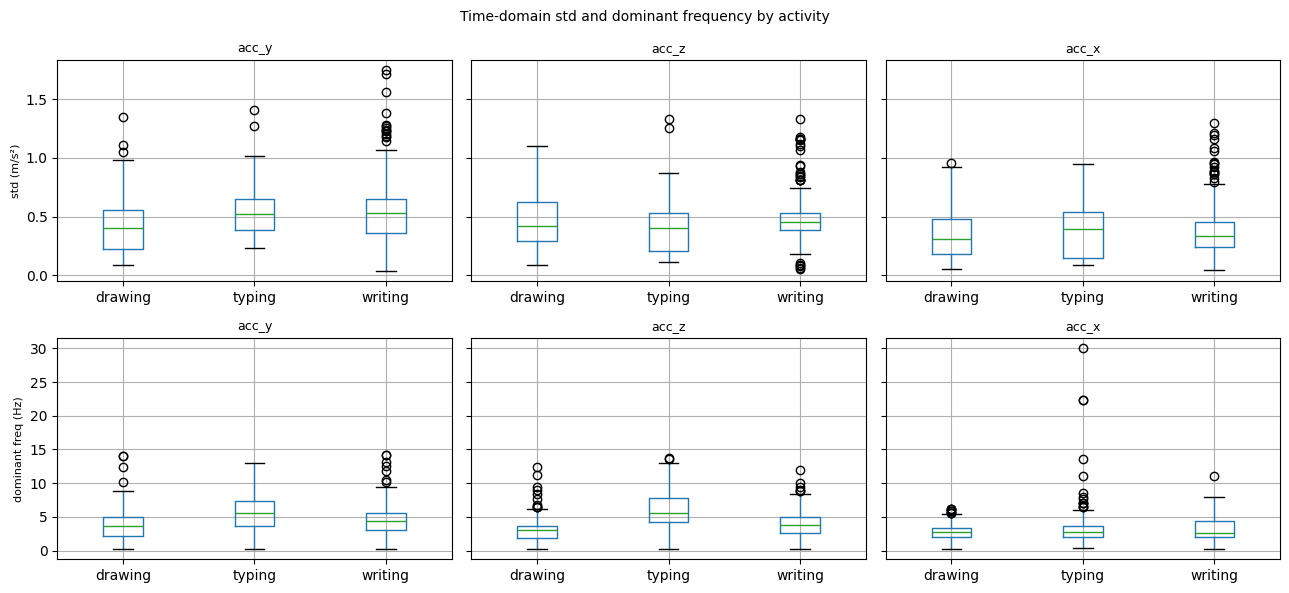

label                          drawing  typing  writing
WatchAccelerometer_y_std         0.426   0.533    0.533
WatchAccelerometer_y_max_freq    3.648   5.566    4.472
WatchAccelerometer_y_pse         3.508   4.399    3.903
WatchAccelerometer_z_std         0.456   0.385    0.471
WatchAccelerometer_z_max_freq    2.996   5.989    3.844
WatchAccelerometer_z_pse         3.541   4.494    4.015
WatchAccelerometer_x_std         0.341   0.369    0.369
WatchAccelerometer_x_max_freq    2.852   3.106    3.146
WatchAccelerometer_x_pse         3.446   3.894    3.567


In [171]:
acc_cols = [col for col in motion_cols if 'Accelerometer' in col]
plot_features = [
    ('std', 'std (m/s²)'),
    ('max_freq', 'dominant freq (Hz)')
]
fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharey='row')

for i, (col, col_axes) in enumerate(zip(acc_cols, axes.T)):
    title = col.replace('WatchAccelerometer_', 'acc_')
    for ax, (feature, ylabel) in zip(col_axes, plot_features):
        features.boxplot(column=f'{col}_{feature}', by='label', ax=ax)
        ax.set_title(title, fontsize=9)
        ax.set_xlabel('')
        if i == 0:
            ax.set_ylabel(ylabel, fontsize=8)

plt.suptitle('Time-domain std and dominant frequency by activity', fontsize=10)
plt.tight_layout()
plt.savefig('figures/feature_analysis.png', dpi=150)
plt.show()

key_cols = [
    f'{col}_{feature}'
    for col in acc_cols
    for feature in ('std', 'max_freq', 'pse')
]
print(features.groupby('label')[key_cols].mean().round(3).T)

# Classical model

## KNN & Decision Tree Classifiers

In [173]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score,
                             f1_score, precision_score, recall_score)
from sklearn.preprocessing import LabelEncoder
import warnings
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

feature_cols = [c for c in features.columns if c not in ('time', 'subject', 'label')]
splits = [
    {'train_subj': 1, 'test_subj': 2},
    {'train_subj': 2, 'test_subj': 1},
]
knn_grid = {
    'n_neighbors': [3, 5, 10, 15],
    'metric':      ['euclidean', 'manhattan'],
}
dt_grid = {
    'max_depth':        [5, 10, 20, None],
    'min_samples_leaf': [2, 10, 50],
    'criterion':        ['gini', 'entropy'],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

In [174]:
for split in splits:
    tr, te = split['train_subj'], split['test_subj']
    key = f'train{tr}_test{te}'

    X_train = features[features['subject'] == tr][feature_cols].values
    y_train = features[features['subject'] == tr]['label'].values
    X_test  = features[features['subject'] == te][feature_cols].values
    y_test  = features[features['subject'] == te]['label'].values

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    knn_search = GridSearchCV(
        KNeighborsClassifier(), knn_grid,
        cv=cv, scoring='f1_macro', n_jobs=-1
    )
    knn_search.fit(X_train, y_train)
    best_knn = knn_search.best_estimator_
    knn_pred = best_knn.predict(X_test)

    dt_search = GridSearchCV(
        DecisionTreeClassifier(random_state=42), dt_grid,
        cv=cv, scoring='f1_macro', n_jobs=-1
    )
    dt_search.fit(X_train, y_train)
    best_dt = dt_search.best_estimator_
    dt_pred = best_dt.predict(X_test)

    results[key] = {
        'y_test':     y_test,
        'knn_pred':   knn_pred,
        'dt_pred':    dt_pred,
        'knn_params': knn_search.best_params_,
        'dt_params':  dt_search.best_params_,
        'dt_model':   best_dt,
        'train_subj': tr,
        'test_subj':  te,
    }

    print(f"\n{'='*60}")
    print(f"  LOSO split: train on subject {tr}, test on subject {te}")
    print(f"{'='*60}")
    print(f"\n  Best KNN params : {knn_search.best_params_}")
    print(f"  Best DT params  : {dt_search.best_params_}")
    print(f"\n  --- KNN classification report ---")
    print(classification_report(y_test, knn_pred, digits=3))
    print(f"  --- Decision Tree classification report ---")
    print(classification_report(y_test, dt_pred, digits=3))


  LOSO split: train on subject 1, test on subject 2

  Best KNN params : {'metric': 'euclidean', 'n_neighbors': 3}
  Best DT params  : {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 10}

  --- KNN classification report ---
              precision    recall  f1-score   support

     drawing      0.090     0.114     0.101        79
      typing      0.067     0.062     0.064       177
     writing      0.384     0.371     0.377       251

    accuracy                          0.223       507
   macro avg      0.180     0.182     0.181       507
weighted avg      0.228     0.223     0.225       507

  --- Decision Tree classification report ---
              precision    recall  f1-score   support

     drawing      0.194     0.177     0.185        79
      typing      0.074     0.011     0.020       177
     writing      0.537     0.873     0.665       251

    accuracy                          0.464       507
   macro avg      0.268     0.354     0.290       507
weighted avg

## Confusion matrices (LOSO)

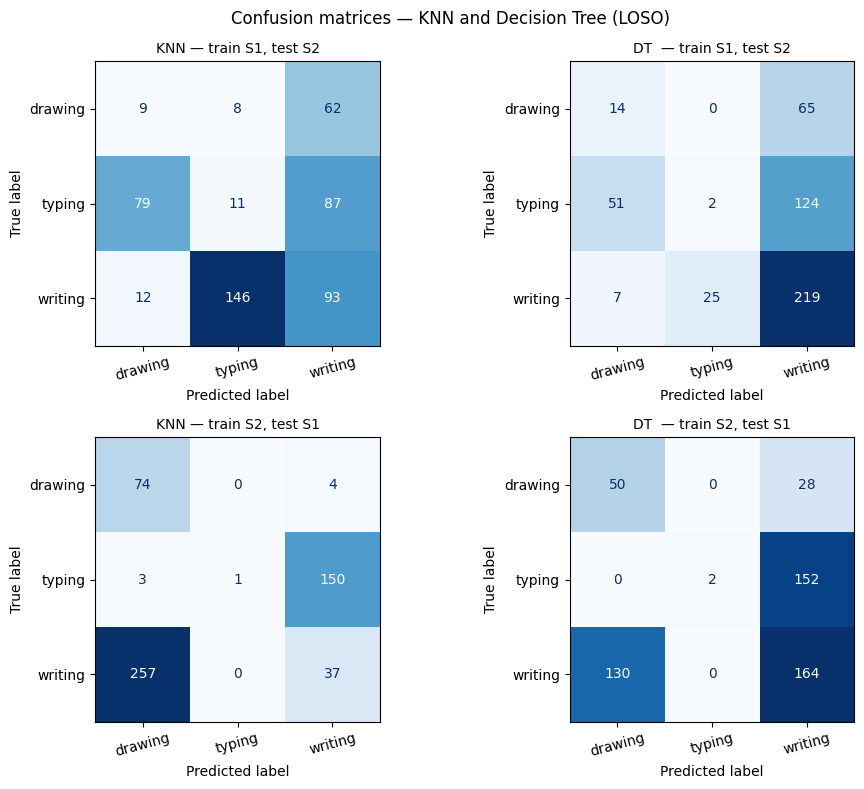

In [175]:
labels_order = sorted(features['label'].unique())

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

plot_configs = [
    ('train1_test2', 'knn_pred', 'KNN — train S1, test S2', axes[0, 0]),
    ('train1_test2', 'dt_pred',  'DT  — train S1, test S2', axes[0, 1]),
    ('train2_test1', 'knn_pred', 'KNN — train S2, test S1', axes[1, 0]),
    ('train2_test1', 'dt_pred',  'DT  — train S2, test S1', axes[1, 1]),
]

for key, pred_key, title, ax in plot_configs:
    r = results[key]
    cm = confusion_matrix(r['y_test'], r[pred_key], labels=labels_order)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Confusion matrices — KNN and Decision Tree (LOSO)', fontsize=12)
plt.tight_layout()
plt.savefig('figures/confusion_matrices_loso.png', dpi=150)
plt.show()

## Feature importance (DT, averaged over both splits)

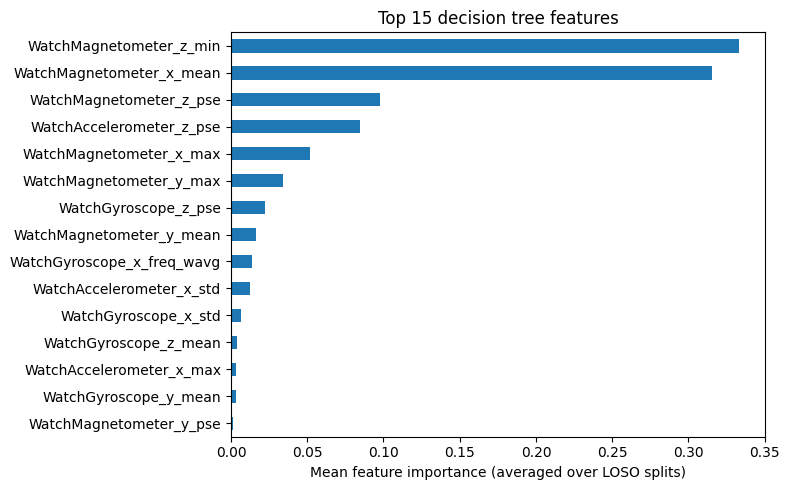


Top 15 features:
WatchMagnetometer_z_min       0.3335
WatchMagnetometer_x_mean      0.3155
WatchMagnetometer_z_pse       0.0976
WatchAccelerometer_z_pse      0.0847
WatchMagnetometer_x_max       0.0515
WatchMagnetometer_y_max       0.0338
WatchGyroscope_z_pse          0.0223
WatchMagnetometer_y_mean      0.0163
WatchGyroscope_x_freq_wavg    0.0138
WatchAccelerometer_x_std      0.0122
WatchGyroscope_x_std          0.0069
WatchGyroscope_z_mean         0.0040
WatchAccelerometer_x_max      0.0032
WatchGyroscope_y_mean         0.0030
WatchMagnetometer_y_pse       0.0013


In [176]:
importances = (
    results['train1_test2']['dt_model'].feature_importances_ +
    results['train2_test1']['dt_model'].feature_importances_
) / 2

imp_df = (
    pd.Series(importances, index=feature_cols)
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(8, 5))
imp_df[::-1].plot.barh(ax=ax)
ax.set_xlabel('Mean feature importance (averaged over LOSO splits)')
ax.set_title('Top 15 decision tree features')
plt.tight_layout()
plt.savefig('figures/dt_feature_importance.png', dpi=150)
plt.show()

print("\nTop 15 features:")
print(imp_df.round(4).to_string())

## Summary table

In [177]:
rows = []
for key, r in results.items():
    for model_name, pred_key in [('KNN', 'knn_pred'), ('Decision Tree', 'dt_pred')]:
        rows.append({
            'Split':        f"train S{r['train_subj']} / test S{r['test_subj']}",
            'Model':        model_name,
            'Accuracy':     round(accuracy_score(r['y_test'], r[pred_key]), 3),
            'Macro F1':     round(f1_score(r['y_test'], r[pred_key], average='macro'), 3),
            'Macro Prec':   round(precision_score(r['y_test'], r[pred_key], average='macro'), 3),
            'Macro Recall': round(recall_score(r['y_test'], r[pred_key], average='macro'), 3),
        })

summary_table = pd.DataFrame(rows)
print("\nSummary table:")
print(summary_table.to_string(index=False))


Summary table:
             Split         Model  Accuracy  Macro F1  Macro Prec  Macro Recall
train S1 / test S2           KNN     0.223     0.181       0.180         0.182
train S1 / test S2 Decision Tree     0.464     0.290       0.268         0.354
train S2 / test S1           KNN     0.213     0.175       0.472         0.360
train S2 / test S1 Decision Tree     0.411     0.309       0.585         0.404


## Plot confusion matrices

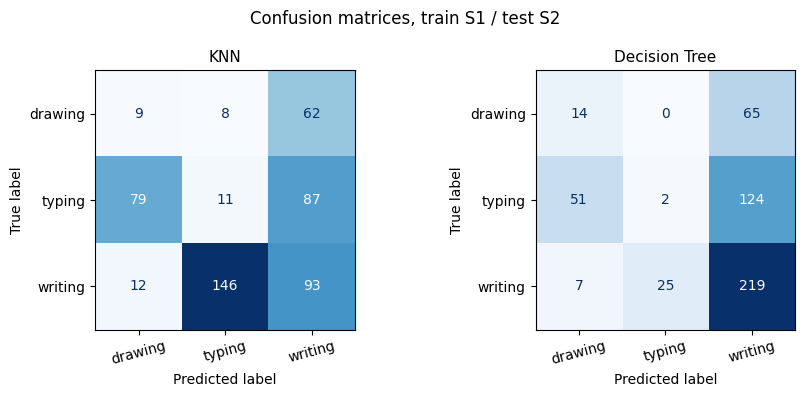

In [178]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for pred_key, title, ax in [('knn_pred', 'KNN', axes[0]), ('dt_pred', 'Decision Tree', axes[1])]:
    r = results['train1_test2']
    cm = confusion_matrix(r['y_test'], r[pred_key], labels=labels_order)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis='x', rotation=15)
plt.suptitle('Confusion matrices, train S1 / test S2', fontsize=12)
plt.tight_layout()
plt.savefig('figures/confusion_matrices.png', dpi=150)
plt.show()

# Deep Learning: CNN-LSTM
In this section, a deep learning approach is taken. A CNN-LSTM model, inspired by Oluwalade et al., is trained for the HAR task: determining the activity type label (drawing, typing, writing, or outside/misc).

## Data Preparation
The shape of the input data is inspected below.

In [28]:
print(df.shape)
print(df['label'].value_counts(dropna=False))

(345092, 12)
label
writing    152403
typing      90803
drawing     51203
None        50683
Name: count, dtype: int64


In [29]:
subj1_df = df[df['subject'] == 1]
print(subj1_df.describe())

                                time   subject  WatchGyroscope_y  \
count                         151027  151027.0     151027.000000   
mean   2026-06-06 18:42:56.009999360       1.0         -0.008544   
min       2026-06-06 18:30:20.880000       1.0         -0.805120   
25%    2026-06-06 18:36:38.444999936       1.0         -0.046426   
50%    2026-06-06 18:42:56.009999872       1.0         -0.006109   
75%    2026-06-06 18:49:13.575000064       1.0          0.032987   
max       2026-06-06 18:55:31.140000       1.0          0.788016   
std                              NaN       0.0          0.142802   

       WatchGyroscope_z  WatchGyroscope_x  WatchAccelerometer_y  \
count     151027.000000     151027.000000         151027.000000   
mean           0.005043         -0.002259             -0.095702   
min           -0.900415         -1.806939             -2.916138   
25%           -0.025656         -0.059865             -0.287304   
50%            0.003665          0.000000           

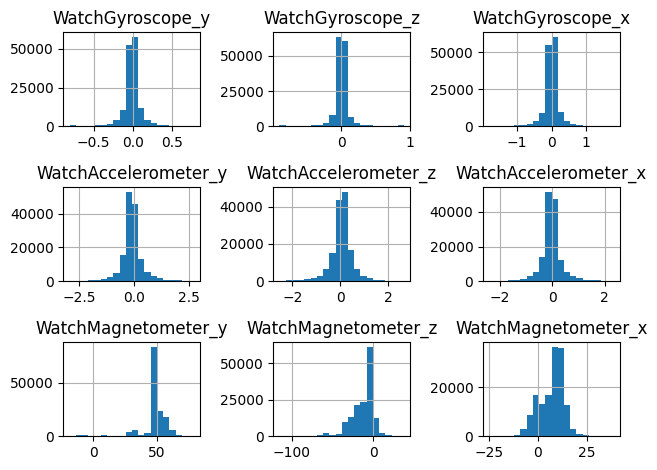

In [30]:
subj1_df[motion_cols].hist(bins=20)
plt.tight_layout()
plt.show()

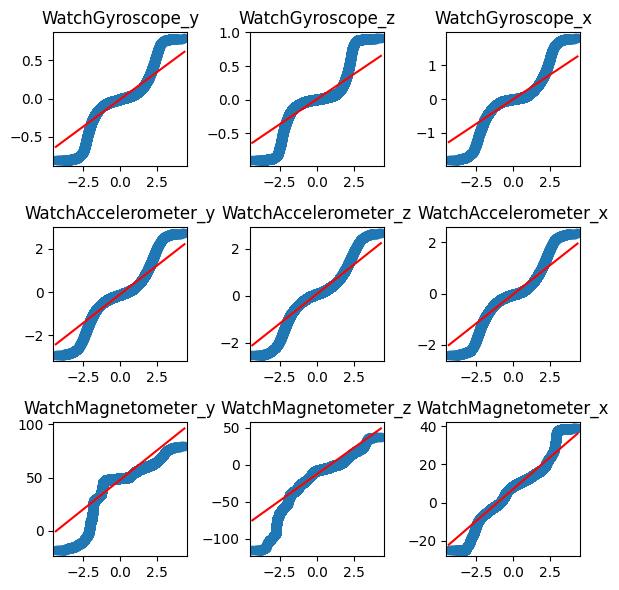

In [31]:
from statsmodels.graphics.gofplots import qqplot
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(6,6))
ax = ax.flatten()
for i, col in enumerate(motion_cols):
    s = subj1_df[col]
    qqplot(s, line='s', ax=ax[i])
    ax[i].set_title(col)
    ax[i].set_xlabel("")
    ax[i].set_ylabel("")
plt.tight_layout()
plt.show()

In [32]:
for col in motion_cols:
    s = subj1_df[col]
    stat, p = stats.normaltest(s)
    print(f'Statistic={stat:.3f}, p={p:e}')

Statistic=29460.896, p=0.000000e+00
Statistic=37904.750, p=0.000000e+00
Statistic=29199.310, p=0.000000e+00
Statistic=21214.812, p=0.000000e+00
Statistic=19110.302, p=0.000000e+00
Statistic=19899.875, p=0.000000e+00
Statistic=96076.179, p=0.000000e+00
Statistic=51912.650, p=0.000000e+00
Statistic=9036.954, p=0.000000e+00


Each D'Agostino's $K^2$ test result gives an extremely small p-value of approximately zero, much smaller than the significance level $\alpha=0.05$. Therefore, for each data series, the null hypothesis $H_0$ that the sample is Gaussian, is rejected. Thus, it is unlikely that the data of any of the motion columns are Gaussian.

## Data Normalization

As the data distributions are unlikely to be normal, each series of the training data is normalized with sci-kitlearn's `MinMaxScaler`. To avoid data leakage, each scaler that was fitted on the training data (i.e., subject 1) is used to normalize the test data (i.e., subject 2) and validation data (i.e., subject 3(=1b)) of the corresponding sensor-axis combination.

In [33]:
# Subject 1: Training set
scalers = dict()
normalized_df = df.copy()
print("Ranges pre-normalization:")
for col in motion_cols:
    s = normalized_df[normalized_df['subject'] == 1][col]
    vals = s.values
    reshaped_vals = vals.reshape(len(vals), 1)
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaler.fit(reshaped_vals)
    print(f'{col} - Min: {scaler.data_min_}, Max: {scaler.data_max_}')
    normalized = scaler.transform(reshaped_vals)
    norm_reshaped = normalized.reshape(len(vals))
    normalized_df.loc[normalized_df['subject'] == 1, col] = norm_reshaped
    scalers[col] = scaler

print("\nTrain (subj1) -  Post-normalization:")
print(normalized_df[normalized_df['subject'] == 1].describe())

# Subject 2: Test set
for col in motion_cols:
    s = normalized_df[normalized_df['subject'] == 2][col]
    vals = s.values
    reshaped_vals = vals.reshape(len(vals), 1)
    scaler = scalers[col]

    normalized = scaler.transform(reshaped_vals)
    norm_reshaped = normalized.reshape(len(vals))
    normalized_df.loc[normalized_df['subject'] == 2, col] = norm_reshaped

print("\nTest (subj2) -  Post-normalization:")
print(normalized_df[normalized_df['subject'] == 2].describe())

# Subject 3 (=1b): Validation set
for col in motion_cols:
    s = normalized_df[normalized_df['subject'] == 3][col]
    vals = s.values
    reshaped_vals = vals.reshape(len(vals), 1)
    scaler = scalers[col]

    normalized = scaler.transform(reshaped_vals)
    norm_reshaped = normalized.reshape(len(vals))
    normalized_df.loc[normalized_df['subject'] == 3, col] = norm_reshaped

print("\nValidation (subj3=1b) -  Post-normalization:")
print(normalized_df[normalized_df['subject'] == 3].describe())

Ranges pre-normalization:
WatchGyroscope_y - Min: [-0.80512041], Max: [0.78801614]
WatchGyroscope_z - Min: [-0.90041536], Max: [0.91141093]
WatchGyroscope_x - Min: [-1.80693936], Max: [1.80083072]
WatchAccelerometer_y - Min: [-2.9161377], Max: [2.71981311]
WatchAccelerometer_z - Min: [-2.53785372], Max: [2.65995812]
WatchAccelerometer_x - Min: [-2.39899015], Max: [2.34631777]
WatchMagnetometer_y - Min: [-18.47999954], Max: [79.31999969]
WatchMagnetometer_z - Min: [-115.37999725], Max: [37.61999893]
WatchMagnetometer_x - Min: [-24.89999962], Max: [38.81999969]

Train (subj1) -  Post-normalization:
                                time   subject  WatchGyroscope_y  \
count                         151027  151027.0     151027.000000   
mean   2026-06-06 18:42:56.009999360       1.0          0.500005   
min       2026-06-06 18:30:20.880000       1.0          0.000000   
25%    2026-06-06 18:36:38.444999936       1.0          0.476227   
50%    2026-06-06 18:42:56.009999872       1.0          

Some of the normalized ranges of the sensor data in the test set (subject 2) and validation set (subject3(=1b)) exceed the normalized range of the training data ($[0, 1]$). E.g., in the test data, the z-axis of the Gyroscope sensor has a range of ca. $[-0.4, 1.4]$ post-normalization, indicating that the pre-normalization range of this data is wider than the pre-normalization range of the corresponding training data.

In [34]:
def window_label_split(df, motion_cols, window, step):
    rows = []
    train_rows = []
    test_rows = []
    val_rows = []
    
    for subj in [1, 2, 3]:
        subj_df = df[df['subject'] == subj].reset_index(drop=True)
        vals   = subj_df[motion_cols].values
        labels = subj_df['label'].values
        times  = subj_df['time'].values
        n      = len(subj_df)

        for t in range(window - 1, n, step):
            label = labels[t]
            if label is None:
                label = 'OUTSIDE'
            row = {'time': times[t], 'subject': subj, 'label': label}
            rows.append(row)

            # 200 instances in a time window of 2 sec, with 9 sensors,
            # gives a matrix of shape (200, 9) for each row (i.e., window)
            win = vals[t - window + 1 : t + 1]

            if subj == 1:  # Subject 1: Training set
                train_rows.append(win)
            elif subj == 2:  # Subject 2: Test set
                test_rows.append(win)
            elif subj == 3:  # Subject 3(=1b): Validation set
                val_rows.append(win)
                
    X_train = np.asarray(train_rows)
    X_test = np.asarray(test_rows)
    X_val = np.asarray(val_rows)
    windowed_df = pd.DataFrame(rows).reset_index(drop=True)

    return windowed_df, X_train, X_test, X_val

WINDOW  = 200                          
OVERLAP = 0.5                          
STEP    = int(WINDOW * (1 - OVERLAP))

windowed_df, X_train, X_test, X_val = window_label_split(normalized_df, motion_cols, WINDOW, STEP)

In [35]:
# Encode the string labels to integers for all subjects
le = LabelEncoder()
label_series = windowed_df['label']
le.fit(label_series)
label_ints = le.transform(label_series)
windowed_df['label_int'] = label_ints

print(windowed_df['label'].value_counts())
print(windowed_df['label_int'].value_counts())
print(windowed_df.shape)
print(windowed_df.head())

label
writing    1524
typing      908
drawing     512
OUTSIDE     503
Name: count, dtype: int64
label_int
3    1524
2     908
1     512
0     503
Name: count, dtype: int64
(3447, 4)
                     time  subject    label  label_int
0 2026-06-06 18:30:22.870        1  OUTSIDE          0
1 2026-06-06 18:30:23.870        1  OUTSIDE          0
2 2026-06-06 18:30:24.870        1  OUTSIDE          0
3 2026-06-06 18:30:25.870        1  OUTSIDE          0
4 2026-06-06 18:30:26.870        1  OUTSIDE          0


In [36]:
# Split the dataFrame into train (subj1), test (subj2) 
# and validation (subj3(=1b))
train_df = windowed_df[windowed_df['subject'] == 1]
test_df = windowed_df[windowed_df['subject'] == 2]
val_df = windowed_df[windowed_df['subject'] == 3]

# Convert integer classes to one-hot vectors
train_label_ints = train_df['label_int']
test_label_ints = test_df['label_int']
val_label_ints = val_df['label_int']
train_y: np.ndarray = keras.utils.to_categorical(
    train_label_ints, 
    num_classes=4
)
test_y: np.ndarray = keras.utils.to_categorical(
    test_label_ints, 
    num_classes=4
)
val_y: np.ndarray = keras.utils.to_categorical(
    val_label_ints, 
    num_classes=4
)

print(train_df['label'].value_counts())
print(train_df['label_int'].value_counts())
print(train_df.shape)
print(train_df.head())
print(train_y)
print(train_y.shape)

label
writing    735
typing     387
drawing    195
OUTSIDE    192
Name: count, dtype: int64
label_int
3    735
2    387
1    195
0    192
Name: count, dtype: int64
(1509, 4)
                     time  subject    label  label_int
0 2026-06-06 18:30:22.870        1  OUTSIDE          0
1 2026-06-06 18:30:23.870        1  OUTSIDE          0
2 2026-06-06 18:30:24.870        1  OUTSIDE          0
3 2026-06-06 18:30:25.870        1  OUTSIDE          0
4 2026-06-06 18:30:26.870        1  OUTSIDE          0
[[1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 ...
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]]
(1509, 4)


In [37]:
print(test_df['label'].value_counts())
print(test_df['label_int'].value_counts())
print(test_df.shape)
print(test_df.head())
print(test_y)
print(test_y.shape)

label
writing    627
typing     443
OUTSIDE    248
drawing    198
Name: count, dtype: int64
label_int
3    627
2    443
0    248
1    198
Name: count, dtype: int64
(1516, 4)
                        time  subject    label  label_int
1509 2026-06-06 19:07:42.600        2  OUTSIDE          0
1510 2026-06-06 19:07:43.600        2  OUTSIDE          0
1511 2026-06-06 19:07:44.600        2  OUTSIDE          0
1512 2026-06-06 19:07:45.600        2  OUTSIDE          0
1513 2026-06-06 19:07:46.600        2  OUTSIDE          0
[[1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 ...
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]]
(1516, 4)


In [38]:
print(val_df['label'].value_counts())
print(val_df['label_int'].value_counts())
print(val_df.shape)
print(val_df.head())
print(val_y)
print(val_y.shape)

label
writing    162
drawing    119
typing      78
OUTSIDE     63
Name: count, dtype: int64
label_int
3    162
1    119
2     78
0     63
Name: count, dtype: int64
(422, 4)
                        time  subject    label  label_int
3025 2026-06-18 06:30:24.550        3  OUTSIDE          0
3026 2026-06-18 06:30:25.550        3  OUTSIDE          0
3027 2026-06-18 06:30:26.550        3  OUTSIDE          0
3028 2026-06-18 06:30:27.550        3  OUTSIDE          0
3029 2026-06-18 06:30:28.550        3  OUTSIDE          0
[[1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 ...
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]]
(422, 4)


There are 1509 windows in the training set, 422 windows in the validation set, and 1516 windows in the test set. I.e., the training\:validation\:test split is approximately 44\:12\:44.

In [69]:
sum_windows = 1509+422+1516
print(f"{100*1509/sum_windows:.0f}")
print(f"{100*422/sum_windows:.0f}")
print(f"{100*1516/sum_windows:.0f}")

44
12
44


In [39]:
print(X_train.shape)
print(train_y.shape)

(1509, 200, 9)
(1509, 4)


## Hyperparameter optimization

The Adam learning rate, number of LSTM units, number of CNN filters, and CNN kernel size are tuned. With three values per hyperparameter, the total number of configurations in the search space equals $3^4=81$.

In [40]:
def build_model(hp):
    model = Sequential()
    model.add(Conv1D(
        filters=hp.Int('filters', min_value=32, max_value=128, step=2, sampling='log'),
        kernel_size=hp.Int('kernel_size', min_value=3, max_value=5, step=1),
        activation='relu'
    ))
    model.add(Dropout(0.4))
    model.add(LSTM(hp.Int('LSTM_units', min_value=64, max_value=256, step=2, sampling='log')))
    model.add(Dense(100, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(
        4,  # n_outputs: 4 classes
        activation='softmax'
    ))
    learning_rate=hp.Float("lr", min_value=1e-4, max_value=1e-2, step=10, sampling="log")
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy', 
        metrics=[F1Score(average='macro', name='macro_f1')]
    )
    return model

build_model(keras_tuner.HyperParameters())

<Sequential name=sequential, built=False>

In [41]:
tuner = keras_tuner.RandomSearch(
    hypermodel=build_model,
    objective=keras_tuner.Objective('val_macro_f1', direction='max'),
    max_trials=27,
    executions_per_trial=2,
    overwrite=False,
    directory='search',
    project_name='lr_cnn_lstm',
)

tuner.search_space_summary()

Search space summary
Default search space size: 4
filters (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 2, 'sampling': 'log'}
kernel_size (Int)
{'default': None, 'conditions': [], 'min_value': 3, 'max_value': 5, 'step': 1, 'sampling': 'linear'}
LSTM_units (Int)
{'default': None, 'conditions': [], 'min_value': 64, 'max_value': 256, 'step': 2, 'sampling': 'log'}
lr (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.01, 'step': 10, 'sampling': 'log'}


In [42]:
print("Search starting...")
tuner.search(X_train, train_y, epochs=2, validation_data=(X_val, val_y))
print("Search finished!")

Trial 27 Complete [00h 02m 01s]
val_macro_f1: 0.23531847447156906

Best val_macro_f1 So Far: 0.431353822350502
Total elapsed time: 01h 05m 19s
Search finished!


### Tuning search results

In [51]:
tuner.results_summary()

Results summary
Results in search\lr_cnn_lstm
Showing 10 best trials
Objective(name="val_macro_f1", direction="max")

Trial 15 summary
Hyperparameters:
filters: 128
kernel_size: 3
LSTM_units: 64
lr: 0.001
Score: 0.431353822350502

Trial 16 summary
Hyperparameters:
filters: 32
kernel_size: 5
LSTM_units: 64
lr: 0.001
Score: 0.3335719555616379

Trial 02 summary
Hyperparameters:
filters: 32
kernel_size: 4
LSTM_units: 64
lr: 0.01
Score: 0.3289894312620163

Trial 22 summary
Hyperparameters:
filters: 128
kernel_size: 3
LSTM_units: 256
lr: 0.0001
Score: 0.3218541890382767

Trial 08 summary
Hyperparameters:
filters: 64
kernel_size: 3
LSTM_units: 64
lr: 0.001
Score: 0.2994432672858238

Trial 14 summary
Hyperparameters:
filters: 32
kernel_size: 4
LSTM_units: 128
lr: 0.001
Score: 0.273300938308239

Trial 09 summary
Hyperparameters:
filters: 64
kernel_size: 4
LSTM_units: 128
lr: 0.001
Score: 0.27048446983098984

Trial 18 summary
Hyperparameters:
filters: 128
kernel_size: 3
LSTM_units: 128
lr: 0.001

In [46]:
models = tuner.get_best_models(num_models=2)
best_model = models[0]
best_model.summary()

C:\Users\kevyn\anaconda3\envs\group8_310\lib\site-packages\keras\src\saving\saving_lib.py:794: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 28 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (32, 198, 128)              │           3,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (32, 198, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (32, 64)                    │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (32, 100)                   │           6,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (32, 64)                    │           6,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (32, 64)                    │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (32, 32)                    │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (32, 4)                     │             132 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 68,168 (266.28 KB)

 Trainable params: 68,168 (266.28 KB)

 Non-trainable params: 0 (0.00 B)

## Model training and testing

In [64]:
def evaluate_model(best_hps, X_train, train_y, X_test, test_y, X_val, val_y, r: int):
    # Early stopping: min. val loss with patience
    # Only save the model with the best Macro F1
    batch_size = 32
    model_filename = f"models/repeat_{r}_best_model.keras"
    es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=20)
    mc = ModelCheckpoint(
        model_filename, 
        monitor='val_macro_f1', 
        mode='max',
        save_best_only=True,
        verbose=1
    )
    model = build_model(best_hps[0])
    model.fit(
        X_train, 
        train_y, 
        validation_data=(X_val, val_y),
        epochs=1000,
        batch_size=batch_size,
        verbose=True,
        callbacks=[es, mc]
    )
    # Collect the predictions
    raw_pred_probabilities = model.predict(
        X_test, 
        batch_size=batch_size, 
        verbose=True
    )
    test_y_pred = np.argmax(raw_pred_probabilities, axis=1)
    test_y_true = np.argmax(test_y, axis=1)
    target_names = le.classes_
    scores = classification_report(
        test_y_true,
        test_y_pred,
        target_names=target_names,
        output_dict=True
    )
    return scores

def run_experiment(best_hps, X_train, train_y, X_test, test_y, X_val, val_y, repeats=10):
    start = perf_counter()
    score_rows = []
    for r in range(repeats):
        scores = evaluate_model(
            best_hps, X_train, train_y, X_test, test_y, X_val, val_y, r
        )
        score_rows.append(scores)
    end = perf_counter()
    print("Time elapsed:", datetime.timedelta(seconds=(end - start)))
    return score_rows

repeats = 3
best_hps = tuner.get_best_hyperparameters(1)  # best params from tuning search
score_rows = run_experiment(
    best_hps, X_train, train_y, X_test, test_y, X_val, val_y, repeats=repeats
)

Epoch 1/1000
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 543ms/step - loss: 1.2576 - macro_f1: 0.1829
Epoch 1: val_macro_f1 improved from None to 0.20823, saving model to models/repeat_0_best_model.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 31s 652ms/step - loss: 1.2045 - macro_f1: 0.1930 - val_loss: 1.4100 - val_macro_f1: 0.2082
Epoch 2/1000
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 534ms/step - loss: 1.1906 - macro_f1: 0.2825
Epoch 2: val_macro_f1 did not improve from 0.20823
48/48 ━━━━━━━━━━━━━━━━━━━━ 30s 637ms/step - loss: 1.2027 - macro_f1: 0.2696 - val_loss: 1.3445 - val_macro_f1: 0.1467
Epoch 3/1000
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - loss: 1.1842 - macro_f1: 0.2247
Epoch 3: val_macro_f1 did not improve from 0.20823
48/48 ━━━━━━━━━━━━━━━━━━━━ 30s 617ms/step - loss: 1.1458 - macro_f1: 0.2917 - val_loss: 1.5714 - val_macro_f1: 0.1389
Epoch 4/1000
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 517ms/step - loss: 1.1756 - macro_f1: 0.2669
Epoch 4: val_macro_f1 improved from 0.20823 to 0.30757, saving model to models/repeat_0_be

C:\Users\kevyn\anaconda3\envs\group8_310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kevyn\anaconda3\envs\group8_310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kevyn\anaconda3\envs\group8_310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

Epoch 1/1000
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 555ms/step - loss: 1.2697 - macro_f1: 0.1760
Epoch 1: val_macro_f1 improved from None to 0.37487, saving model to models/repeat_1_best_model.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 32s 672ms/step - loss: 1.2063 - macro_f1: 0.2136 - val_loss: 1.2731 - val_macro_f1: 0.3749
Epoch 2/1000
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 534ms/step - loss: 1.0663 - macro_f1: 0.3276
Epoch 2: val_macro_f1 improved from 0.37487 to 0.43627, saving model to models/repeat_1_best_model.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 31s 642ms/step - loss: 0.9637 - macro_f1: 0.3608 - val_loss: 1.0504 - val_macro_f1: 0.4363
Epoch 3/1000
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 526ms/step - loss: 0.7118 - macro_f1: 0.5189
Epoch 3: val_macro_f1 did not improve from 0.43627
48/48 ━━━━━━━━━━━━━━━━━━━━ 30s 635ms/step - loss: 0.7434 - macro_f1: 0.5119 - val_loss: 1.2202 - val_macro_f1: 0.3760
Epoch 4/1000
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 538ms/step - loss: 0.9849 - macro_f1: 0.3871
Epoch 4: val_macro_f1 did not improv

C:\Users\kevyn\anaconda3\envs\group8_310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kevyn\anaconda3\envs\group8_310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kevyn\anaconda3\envs\group8_310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

Epoch 1/1000
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 533ms/step - loss: 1.2746 - macro_f1: 0.2055
Epoch 1: val_macro_f1 improved from None to 0.37911, saving model to models/repeat_2_best_model.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 31s 639ms/step - loss: 1.1990 - macro_f1: 0.2392 - val_loss: 1.2171 - val_macro_f1: 0.3791
Epoch 2/1000
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 528ms/step - loss: 1.1242 - macro_f1: 0.2827
Epoch 2: val_macro_f1 did not improve from 0.37911
48/48 ━━━━━━━━━━━━━━━━━━━━ 31s 639ms/step - loss: 1.1437 - macro_f1: 0.2823 - val_loss: 1.1531 - val_macro_f1: 0.3696
Epoch 3/1000
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 518ms/step - loss: 1.1609 - macro_f1: 0.3195
Epoch 3: val_macro_f1 improved from 0.37911 to 0.41199, saving model to models/repeat_2_best_model.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 30s 623ms/step - loss: 1.0341 - macro_f1: 0.3557 - val_loss: 1.0242 - val_macro_f1: 0.4120
Epoch 4/1000
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 535ms/step - loss: 0.8768 - macro_f1: 0.4594
Epoch 4: val_macro_f1 improved from 

C:\Users\kevyn\anaconda3\envs\group8_310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kevyn\anaconda3\envs\group8_310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kevyn\anaconda3\envs\group8_310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

## Evaluation results

In [84]:
macro_f1_scores = []
precision_scores = {}
recall_scores = {}
f1_scores = {}
class_cols = le.classes_

for col in class_cols:
    precision_scores[col] = []
    recall_scores[col] = []
    f1_scores[col] = []

for i in range(repeats):
    scores = score_rows[i]
    macro_f1_score = scores['macro avg']['f1-score']
    macro_f1_scores.append(macro_f1_score)
    scores_df = pd.DataFrame(scores)

    for col in class_cols:
        s = scores_df[col]
        precision_scores[col].append(s['precision'])
        recall_scores[col].append(s['recall'])
        f1_scores[col].append(s['f1-score'])

score_dicts = [precision_scores, recall_scores, f1_scores]
macro_f1_series = pd.Series(macro_f1_scores)
precision_df = pd.DataFrame(precision_scores)
recall_df = pd.DataFrame(recall_scores)
f1_scores_df = pd.DataFrame(f1_scores)
merged_scores_df = pd.DataFrame()
merged_scores_df['precision_mean'] = precision_df.mean()
merged_scores_df['precision_stdev'] = precision_df.std()
merged_scores_df['recall_mean'] = recall_df.mean()
merged_scores_df['recall_stdev'] = recall_df.std()
merged_scores_df['f1-scores_mean'] = f1_scores_df.mean()
merged_scores_df['f1-scores_stdev'] = f1_scores_df.std()

### Macro-averaged F1 score

In [85]:
print("Macro F1 per run:")
print(macro_f1_series, "\n")
print("Macro F1 Mean:", macro_f1_series.mean())
print("Macro F1 Stdev:", macro_f1_series.std())

Macro F1 per run:
0    0.182105
1    0.211140
2    0.233562
dtype: float64 

Macro F1 Mean: 0.20893571000985509
Macro F1 Stdev: 0.025799353102153186


### Precision scores

In [86]:
print("Precision per run (by class):")
print(precision_df, "\n")
print("Precision Mean (by class):")
print(merged_scores_df['precision_mean'], "\n")
print("Precision Stdev (by class):")
print(merged_scores_df['precision_stdev'])

Precision per run (by class):
    OUTSIDE  drawing    typing   writing
0  0.161983      0.0  0.021739  0.776923
1  0.149573      0.0  0.012658  0.574150
2  0.190476      0.0  0.015152  0.619614 

Precision Mean (by class):
OUTSIDE    0.167344
drawing    0.000000
typing     0.016516
writing    0.656895
Name: precision_mean, dtype: float64 

Precision Stdev (by class):
OUTSIDE    0.020972
drawing    0.000000
typing     0.004692
writing    0.106404
Name: precision_stdev, dtype: float64


### Recall scores

In [87]:
print("Recall per run (by class):")
print(recall_df, "\n")
print("Recall Mean (by class):")
print(recall_df.mean(), "\n")
print("Recall Stdev (by class):")
print(recall_df.std())

Recall per run (by class):
    OUTSIDE  drawing    typing   writing
0  0.790323      0.0  0.002257  0.322169
1  0.423387      0.0  0.002257  0.673046
2  0.596774      0.0  0.002257  0.665072 

Recall Mean (by class):
OUTSIDE    0.603495
drawing    0.000000
typing     0.002257
writing    0.553429
dtype: float64 

Recall Stdev (by class):
OUTSIDE    0.183560
drawing    0.000000
typing     0.000000
writing    0.200317
dtype: float64


### F1-scores

In [88]:
print("F1-scores per run (by class):")
print(f1_scores_df, "\n")
print("F1-scores Mean (by class):")
print(merged_scores_df['f1-scores_mean'], "\n")
print("F1-scores Stdev (by class):")
print(merged_scores_df['f1-scores_stdev'])

F1-scores per run (by class):
    OUTSIDE  drawing    typing   writing
0  0.268861      0.0  0.004090  0.455468
1  0.221053      0.0  0.003831  0.619677
2  0.288780      0.0  0.003929  0.641538 

F1-scores Mean (by class):
OUTSIDE    0.259565
drawing    0.000000
typing     0.003950
writing    0.572228
Name: f1-scores_mean, dtype: float64 

F1-scores Stdev (by class):
OUTSIDE    0.034808
drawing    0.000000
typing     0.000131
writing    0.101706
Name: f1-scores_stdev, dtype: float64


### Merged scores

In [89]:
merged_scores_df

,precision_mean,precision_stdev,recall_mean,recall_stdev,f1-scores_mean,f1-scores_stdev
OUTSIDE,0.167344,0.020972,0.603495,0.183560,0.259565,0.034808
drawing,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
typing,0.016516,0.004692,0.002257,0.000000,0.003950,0.000131
writing,0.656895,0.106404,0.553429,0.200317,0.572228,0.101706
